Supplementary Code S5. Model-variant trade-off analysis (FULL vs CLINICAL vs BIOMARKERS)

Purpose.
This notebook consolidates and analyzes the out-of-fold (OOF) outputs generated in Supplementary Codes S2–S4 to quantify and visualize performance–complexity–utility trade-offs across three a priori defined feature-set variants: FULL, CLINICAL, and BIOMARKERS.
The analysis is explicitly descriptive and comparative; no models are re-fitted and no additional feature selection or tuning is performed at this stage.

Scope and inputs

The notebook operates exclusively on artifacts produced in earlier stages of the workflow:

S2 (Nested cross-validation): outer-fold performance estimates for each model and feature-set variant;

S3 (OOF performance summarization): aggregated OOF predictions and bootstrap confidence intervals for discrimination metrics;

S4 (Calibration and decision analysis): OOF-based calibration summaries and decision-curve analysis (DCA).

These artifacts are treated as immutable inputs to ensure strict separation between model development and downstream evaluation.

Key principles (journal-ready)

OOF-only evaluation.
All primary point estimates are derived from out-of-fold predictions, ensuring unbiased performance assessment and full consistency with the nested cross-validation design. Outer-fold means are retained only for descriptive comparison.

Consistent uncertainty quantification.
When available, uncertainty is quantified using patient-level bootstrap confidence intervals computed on OOF predictions. Fold-level variability is reported separately and is not mixed with OOF-based estimates.

Explicit feature governance.
Feature-set variants are predefined and fixed (FULL, CLINICAL, BIOMARKERS). Model complexity is operationalized as the number of governed input predictors, derived from feature-governance outputs generated upstream.

Beyond discrimination.
In addition to ROC AUC and PR AUC, the notebook summarizes probabilistic accuracy (Brier score) and clinical utility (decision-curve analysis) to contextualize discrimination performance.

Leakage-aware interpretation.
Near-perfect discrimination observed in high-dimensional variants (e.g., FULL) is explicitly treated as a diagnostic signal of potential information leakage, rather than evidence of clinical readiness.

No analytical reuse or refitting.
The notebook performs no outcome-dependent preprocessing, hyperparameter tuning, threshold selection, or model refitting, thereby preserving the integrity of upstream validation.

Outputs **pogrubiony tekst**

The notebook generates publication-ready, audit-ready artifacts:

Tables summarizing winner-model performance, feature-set complexity, calibration metrics, and DCA summaries;

Figures illustrating performance–complexity trade-offs (ROC AUC vs. number of predictors) and OOF-based decision-curve analyses;

A machine-readable run log documenting inputs, outputs, software versions, and plotting parameters.

**All outputs are written to:**

results/S5_tradeoff/tables/

results/S5_tradeoff/figures/

results/S5_tradeoff/logs/

Role within the overall workflow

Supplementary Code S5 serves as the final synthesis layer of the leakage-aware modeling pipeline. By holding validation, calibration, and reporting procedures constant, it enables a transparent comparison of performance, complexity, and clinical utility across feature-set variants, and provides the empirical basis for the methodological recommendations articulated in the main text.

## Setup, paths, output directories

In [1]:
from __future__ import annotations

import json
import shutil
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

ROOT = Path("/content") if Path("/content").exists() else Path.cwd()

OUT_DIR = ROOT / "results" / "S5_tradeoff"
FIG_DIR = OUT_DIR / "figures"
TAB_DIR = OUT_DIR / "tables"
LOG_DIR = OUT_DIR / "logs"

for d in (FIG_DIR, TAB_DIR, LOG_DIR):
    d.mkdir(parents=True, exist_ok=True)


wrong_fig_logs = FIG_DIR / "logs"
if wrong_fig_logs.exists() and wrong_fig_logs.is_dir():
    moved = 0
    for p in wrong_fig_logs.glob("*.png"):
        shutil.move(str(p), str(FIG_DIR / p.name))
        moved += 1

    try:
        wrong_fig_logs.rmdir()
    except OSError:
        pass
    print(f"[S5 path-fix] Moved {moved} PNG(s) from {wrong_fig_logs} -> {FIG_DIR}")

print("ROOT:", ROOT)
print("OUT_DIR:", OUT_DIR.resolve())
print("FIG_DIR:", FIG_DIR.resolve())
print("TAB_DIR:", TAB_DIR.resolve())
print("LOG_DIR:", LOG_DIR.resolve())


ROOT: /content
OUT_DIR: /content/results/S5_tradeoff
FIG_DIR: /content/results/S5_tradeoff/figures
TAB_DIR: /content/results/S5_tradeoff/tables
LOG_DIR: /content/results/S5_tradeoff/logs


## Auxiliary functions

In [2]:
SEARCH_ROOTS = [
    ROOT,
    ROOT / "results",
    ROOT / "results" / "S2_nestedcv",
    ROOT / "results" / "S3_benchmark_summary",
    ROOT / "results" / "S3_benchmark_summary" / "tables",
    ROOT / "results" / "S4_calibration_thresholds",
    ROOT / "results" / "S4_calibration_thresholds" / "tables",
]

def find_file(filename: str, roots: List[Path]) -> Path:

    for r in roots:
        p = r / filename
        if p.exists():
            return p


    for r in roots:
        if r.exists():
            hits = list(r.rglob(filename))
            if hits:
                hits = sorted(hits, key=lambda x: len(str(x)))
                return hits[0]

    raise FileNotFoundError(
        f"Missing required file: {filename}\nSearched in:\n - " + "\n - ".join(map(str, roots))
    )

def read_csv_required(name: str) -> Tuple[pd.DataFrame, Path]:
    p = find_file(name, SEARCH_ROOTS)
    df = pd.read_csv(p)
    print(f"Loaded: {p} | shape={df.shape}")
    return df, p

def read_csv_optional(name: str) -> Tuple[Optional[pd.DataFrame], Optional[Path]]:
    try:
        return read_csv_required(name)
    except FileNotFoundError:
        print(f"NOTE: {name} not found.")
        return None, None

def norm_cols(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out.columns = [str(c).strip() for c in out.columns]
    return out

def require_cols(df: pd.DataFrame, cols: List[str], name: str) -> None:
    missing = set(cols) - set(df.columns)
    if missing:
        raise ValueError(f"{name} missing columns: {sorted(missing)}")


## Load data

In [3]:
nestedcv_results, path_results = read_csv_required("nestedcv_results_all_variants.csv")
winner_map, path_winners = read_csv_required("winner_model_by_variant.csv")

nestedcv_results = norm_cols(nestedcv_results)
winner_map = norm_cols(winner_map)

require_cols(
    nestedcv_results,
    ["variant", "model", "outer_fold", "roc_auc", "auprc", "brier"],
    "nestedcv_results_all_variants.csv",
)

if "variant" not in winner_map.columns:
    raise ValueError("winner_model_by_variant.csv must contain 'variant' column.")

if ("winner_model" not in winner_map.columns) and ("model" not in winner_map.columns):
    raise ValueError("winner_model_by_variant.csv must contain 'winner_model' or 'model' column.")

winners = winner_map.copy()
if "winner_model" not in winners.columns:
    winners = winners.rename(columns={"model": "winner_model"})
winners = winners[["variant", "winner_model"]].drop_duplicates()

print("Variants in nestedcv_results:", sorted(nestedcv_results["variant"].unique()))
print("Variants in winners:", sorted(winners["variant"].unique()))

if not set(winners["variant"]).issubset(set(nestedcv_results["variant"])):
    missing_variants = sorted(set(winners["variant"]) - set(nestedcv_results["variant"]))
    raise ValueError(f"Winners contain variants not found in results: {missing_variants}")


Loaded: /content/nestedcv_results_all_variants.csv | shape=(60, 12)
Loaded: /content/winner_model_by_variant.csv | shape=(3, 8)
Variants in nestedcv_results: ['BIOMARKERS', 'CLINICAL', 'FULL']
Variants in winners: ['BIOMARKERS', 'CLINICAL', 'FULL']


## Loading artifacts

In [4]:
winner_metrics, path_winner_metrics = read_csv_optional("winner_oof_metrics_with_bootstrap_ci.csv")
if winner_metrics is not None:
    winner_metrics = norm_cols(winner_metrics)

oof_calib_summary, path_calib = read_csv_optional("oof_calibration_summary.csv")
if oof_calib_summary is not None:
    oof_calib_summary = norm_cols(oof_calib_summary)

oof_dca, path_dca = read_csv_optional("oof_dca_curves.csv")
if oof_dca is not None:
    oof_dca = norm_cols(oof_dca)

pkg_versions = None
path_pkg = None
try:
    path_pkg = find_file("package_versions.json", SEARCH_ROOTS)
    pkg_versions = json.loads(Path(path_pkg).read_text(encoding="utf-8"))
    print(f"Loaded: {path_pkg} | packages={len(pkg_versions)}")
except FileNotFoundError:
    print("NOTE: package_versions.json not found.")


Loaded: /content/winner_oof_metrics_with_bootstrap_ci.csv | shape=(3, 16)
Loaded: /content/oof_calibration_summary.csv | shape=(12, 7)
Loaded: /content/oof_dca_curves.csv | shape=(1188, 7)
Loaded: /content/package_versions.json | packages=5


In [5]:
DEFAULT_VARIANTS = ["FULL", "CLINICAL", "BIOMARKERS"]

features_by_variant: Dict[str, Optional[List[str]]] = {}

for v in DEFAULT_VARIANTS:
    fdf, _p = read_csv_optional(f"features_used_{v}.csv")
    if fdf is None:
        print(f"WARNING: features_used_{v}.csv not found. n_features for {v} will be NA.")
        features_by_variant[v] = None
        continue

    fdf = norm_cols(fdf)

    if "feature" in fdf.columns:
        feats = fdf["feature"].astype(str).tolist()
    else:
        feats = fdf.iloc[:, 0].astype(str).tolist()

    feats = [f.strip() for f in feats if str(f).strip()]
    features_by_variant[v] = feats

def n_features(variant: str) -> float:
    feats = features_by_variant.get(variant)
    return float(len(feats)) if feats is not None else float("nan")

print({k: (len(v) if v is not None else None) for k, v in features_by_variant.items()})


Loaded: /content/features_used_FULL.csv | shape=(69, 2)
Loaded: /content/features_used_CLINICAL.csv | shape=(58, 2)
Loaded: /content/features_used_BIOMARKERS.csv | shape=(10, 2)
{'FULL': 69, 'CLINICAL': 58, 'BIOMARKERS': 10}


## Outer-fold aggregation (S2) for winners + table saving

In [6]:
win_fold = (
    nestedcv_results.merge(
        winners,
        left_on=["variant", "model"],
        right_on=["variant", "winner_model"],
        how="inner",
    )
    .drop(columns=["winner_model"])
)

if win_fold.empty:
    raise ValueError(
        "No rows matched winner models in nestedcv_results. "
        "Check winner_model_by_variant.csv vs nestedcv_results_all_variants.csv."
    )

agg = (
    win_fold.groupby(["variant", "model"], as_index=False)
    .agg(
        n_folds=("outer_fold", "nunique"),
        roc_auc_mean=("roc_auc", "mean"),
        roc_auc_sd=("roc_auc", "std"),
        auprc_mean=("auprc", "mean"),
        auprc_sd=("auprc", "std"),
        brier_mean=("brier", "mean"),
        brier_sd=("brier", "std"),
    )
)

agg["n_features"] = agg["variant"].map(n_features)
agg = agg.sort_values("variant").reset_index(drop=True)

agg_path = TAB_DIR / "S5_winner_outerfold_summary.csv"
agg.to_csv(agg_path, index=False)
print("Saved:", agg_path)

agg


Saved: /content/results/S5_tradeoff/tables/S5_winner_outerfold_summary.csv


,variant,model,n_folds,roc_auc_mean,roc_auc_sd,auprc_mean,auprc_sd,brier_mean,brier_sd,n_features
0,BIOMARKERS,RF,5,0.949524,0.050575,0.934000,0.074027,0.110719,0.030843,10.0
1,CLINICAL,RF,5,0.594286,0.115441,0.616436,0.156740,0.236608,0.009888,58.0
2,FULL,RF,5,0.994286,0.012778,0.993333,0.014907,0.077564,0.057060,69.0


## Tradeoff + OOF + bootstrap CI

In [7]:
tradeoff = agg.copy()


if winner_metrics is not None:
    wm = winner_metrics.copy()
    if "winner_model" in wm.columns and "model" not in wm.columns:
        wm = wm.rename(columns={"winner_model": "model"})

    if ("variant" in wm.columns) and ("model" in wm.columns):
        keep = ["variant", "model"]
        keep += [c for c in wm.columns if c.lower().startswith("oof_")]
        keep += [c for c in wm.columns if "ci" in c.lower()]
        wm = wm.loc[:, list(dict.fromkeys(keep))].drop_duplicates()
        tradeoff = tradeoff.merge(wm, on=["variant", "model"], how="left")
    else:
        print("WARNING: winner_oof_metrics_with_bootstrap_ci.csv lacks (variant, model). Skipping.")


if oof_calib_summary is not None and ("variant" in oof_calib_summary.columns) and ("model" in oof_calib_summary.columns):
    calib = oof_calib_summary.copy()
    cand = [c for c in calib.columns if c.lower().startswith("oof_")]
    calib_small = calib[["variant", "model"] + cand].drop_duplicates()
    tradeoff = tradeoff.merge(calib_small, on=["variant", "model"], how="left", suffixes=("", "_calib"))

tradeoff_path = TAB_DIR / "S5_tradeoff_table_with_winner.csv"
tradeoff.to_csv(tradeoff_path, index=False)
print("Saved:", tradeoff_path)

tradeoff


Saved: /content/results/S5_tradeoff/tables/S5_tradeoff_table_with_winner.csv


,variant,model,n_folds,roc_auc_mean,roc_auc_sd,auprc_mean,auprc_sd,brier_mean,brier_sd,n_features,oof_n,roc_auc_ci95_lo,roc_auc_ci95_hi,auprc_ci95_lo,auprc_ci95_hi,brier_ci95_lo,brier_ci95_hi,oof_roc_auc,oof_auprc,oof_brier
0,BIOMARKERS,RF,5,0.949524,0.050575,0.934000,0.074027,0.110719,0.030843,10.0,57,0.853719,0.986281,0.790555,0.985762,0.077886,0.148542,0.93000,0.892808,0.111469
1,CLINICAL,RF,5,0.594286,0.115441,0.616436,0.156740,0.236608,0.009888,58.0,57,0.446250,0.745031,0.452652,0.732252,0.217163,0.256173,0.60250,0.579670,0.236464
2,FULL,RF,5,0.994286,0.012778,0.993333,0.014907,0.077564,0.057060,69.0,57,0.992500,1.000000,0.991429,1.000000,0.059609,0.096010,0.99875,0.998462,0.077729


## Trade-off chart

Using y_col=oof_roc_auc
CI columns: None, None
NOTE: no compatible uncertainty bars available for chosen y_col


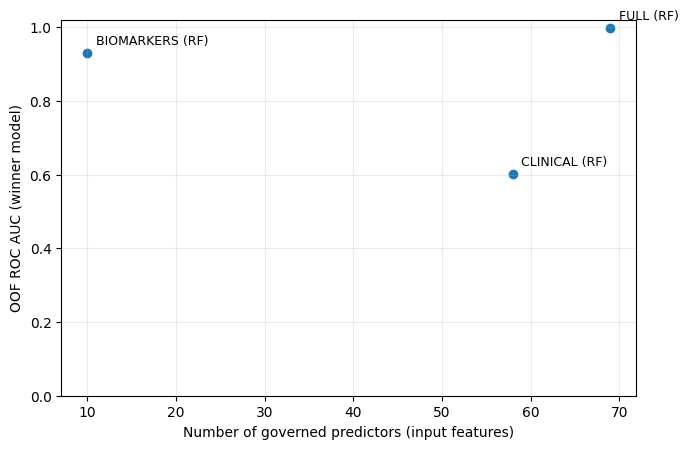

Saved: /content/results/S5_tradeoff/figures/S5_auc_vs_nfeatures.png


In [8]:
def pick_auc_column(df: pd.DataFrame) -> str:
    preferred = ["oof_auc", "oof_roc_auc"]
    for c in preferred:
        if c in df.columns and df[c].notna().all():
            return c
    for c in preferred:
        if c in df.columns and df[c].notna().any():
            print(f"WARNING: Using {c} but it has missing values.")
            return c
    return "roc_auc_mean"

def pick_ci_columns(df: pd.DataFrame) -> Tuple[Optional[str], Optional[str]]:
    pairs = [
        ("oof_auc_ci_low", "oof_auc_ci_high"),
        ("oof_roc_auc_ci_low", "oof_roc_auc_ci_high"),
        ("oof_auc_ci_lower", "oof_auc_ci_upper"),
        ("oof_roc_auc_ci_lower", "oof_roc_auc_ci_upper"),
    ]
    for lo, hi in pairs:
        if lo in df.columns and hi in df.columns and df[lo].notna().all() and df[hi].notna().all():
            return lo, hi
    for lo, hi in pairs:
        if lo in df.columns and hi in df.columns and (df[lo].notna().any() and df[hi].notna().any()):
            print(f"WARNING: Found CI columns {lo}/{hi} with missing values.")
            return lo, hi
    return None, None

y_col = pick_auc_column(tradeoff)
ci_low_col, ci_high_col = pick_ci_columns(tradeoff)

print(f"Using y_col={y_col}")
print(f"CI columns: {ci_low_col}, {ci_high_col}")

x = tradeoff["n_features"].to_numpy(float)
y = tradeoff[y_col].to_numpy(float)

plt.figure(figsize=(7.0, 4.6))
plt.scatter(x, y)

for _, row in tradeoff.iterrows():
    plt.annotate(
        f"{row['variant']} ({row['model']})",
        (float(row["n_features"]), float(row[y_col])),
        textcoords="offset points",
        xytext=(6, 6),
        fontsize=9,
    )

did_errorbars = False
if ci_low_col and ci_high_col and y_col.lower().startswith("oof_"):
    ylo = tradeoff[ci_low_col].to_numpy(float)
    yhi = tradeoff[ci_high_col].to_numpy(float)
    plt.errorbar(x, y, yerr=[y - ylo, yhi - y], fmt="none", capsize=3)
    did_errorbars = True
elif y_col == "roc_auc_mean" and "roc_auc_sd" in tradeoff.columns and tradeoff["roc_auc_sd"].notna().all():
    plt.errorbar(x, y, yerr=tradeoff["roc_auc_sd"].to_numpy(float), fmt="none", capsize=3)
    did_errorbars = True
else:
    print("NOTE: no compatible uncertainty bars available for chosen y_col")

plt.xlabel("Number of governed predictors (input features)")
plt.ylabel(f"{'OOF' if y_col.lower().startswith('oof_') else 'Outer-CV'} ROC AUC (winner model)")
plt.ylim(0.0, 1.02)
plt.grid(True, alpha=0.25)

fig_path = FIG_DIR / "S5_auc_vs_nfeatures.png"
plt.tight_layout()
plt.savefig(fig_path, dpi=300)
plt.show()

print("Saved:", fig_path)


## DCA mean curves

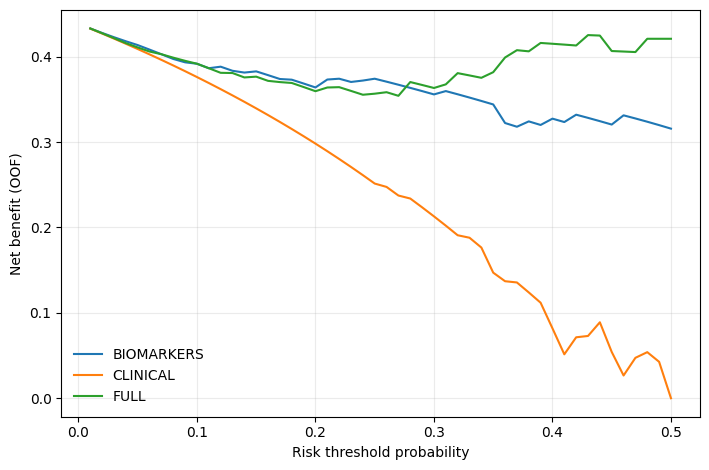

Saved: /content/results/S5_tradeoff/figures/S5_dca_mean_curves_0_0.5.png
Saved: /content/results/S5_tradeoff/tables/S5_dca_mean_curves.csv


In [9]:
if oof_dca is None:
    print("Skipping DCA (oof_dca_curves.csv not available).")
else:
    dca = oof_dca.copy()
    cols = {c.lower(): c for c in dca.columns}

    thr_col = cols.get("threshold")
    nb_col = cols.get("net_benefit")
    vcol = cols.get("variant")
    mcol = cols.get("model")

    if thr_col is None or nb_col is None or vcol is None or mcol is None:
        raise ValueError("oof_dca_curves.csv must contain: variant, model, threshold, net_benefit")

    winners2 = tradeoff[["variant", "model"]].rename(columns={"variant": vcol, "model": mcol})
    dca = dca.merge(winners2, on=[vcol, mcol], how="inner")

    dca = dca[(dca[thr_col] >= 0.0) & (dca[thr_col] <= 0.5)].copy()

    mean_df = (
        dca.groupby([vcol, thr_col], as_index=False)[nb_col]
        .mean()
        .sort_values([vcol, thr_col])
    )

    plt.figure(figsize=(7.2, 4.8))
    for v in mean_df[vcol].unique():
        sub = mean_df[mean_df[vcol] == v]
        plt.plot(sub[thr_col], sub[nb_col], label=str(v))

    plt.xlabel("Risk threshold probability")
    plt.ylabel("Net benefit (OOF)")
    plt.grid(True, alpha=0.25)
    plt.legend(frameon=False)

    fig_path_dca = FIG_DIR / "S5_dca_mean_curves_0_0.5.png"
    plt.tight_layout()
    plt.savefig(fig_path_dca, dpi=300)
    plt.show()
    print("Saved:", fig_path_dca)

    mean_path = TAB_DIR / "S5_dca_mean_curves.csv"
    mean_df.to_csv(mean_path, index=False)
    print("Saved:", mean_path)


## Winner calibration record

In [10]:
if oof_calib_summary is None:
    print("Skipping calibration summary (oof_calibration_summary.csv not available).")
else:
    calib = oof_calib_summary.copy()
    if ("variant" not in calib.columns) or ("model" not in calib.columns):
        raise ValueError("oof_calibration_summary.csv must contain variant and model columns")

    calib_winners = calib.merge(tradeoff[["variant", "model"]], on=["variant", "model"], how="inner")

    out_path = TAB_DIR / "S5_calibration_summary_winners.csv"
    calib_winners.to_csv(out_path, index=False)
    print("Saved:", out_path)

    calib_winners.head()


Saved: /content/results/S5_tradeoff/tables/S5_calibration_summary_winners.csv


## Export package versions + run log (audit trail)

In [11]:

if pkg_versions is not None:
    out = pd.DataFrame(sorted(pkg_versions.items()), columns=["package", "version"])
    out_path = TAB_DIR / "S5_package_versions.csv"
    out.to_csv(out_path, index=False)
    print("Saved:", out_path)

run_log = {
    "random_state": RANDOM_STATE,
    "inputs": {
        "nestedcv_results_all_variants.csv": str(path_results),
        "winner_model_by_variant.csv": str(path_winners),
        "winner_oof_metrics_with_bootstrap_ci.csv": str(path_winner_metrics) if path_winner_metrics else None,
        "oof_calibration_summary.csv": str(path_calib) if path_calib else None,
        "oof_dca_curves.csv": str(path_dca) if path_dca else None,
        "package_versions.json": str(path_pkg) if path_pkg else None,
        "features_used_{VAR}.csv": {k: (len(v) if v is not None else None) for k, v in features_by_variant.items()},
    },
    "outputs": {
        "S5_tradeoff_table_with_winner.csv": str(TAB_DIR / "S5_tradeoff_table_with_winner.csv"),
        "S5_winner_outerfold_summary.csv": str(TAB_DIR / "S5_winner_outerfold_summary.csv"),
        "S5_auc_vs_nfeatures.png": str(FIG_DIR / "S5_auc_vs_nfeatures.png"),
        "S5_dca_mean_curves.csv": str(TAB_DIR / "S5_dca_mean_curves.csv"),
        "S5_dca_mean_curves_0_0.5.png": str(FIG_DIR / "S5_dca_mean_curves_0_0.5.png"),
        "S5_calibration_summary_winners.csv": str(TAB_DIR / "S5_calibration_summary_winners.csv"),
        "S5_package_versions.csv": str(TAB_DIR / "S5_package_versions.csv"),
    },
    "plot_settings": {
        "tradeoff_x": "n_features",
        "tradeoff_y": y_col,
        "ci_low": ci_low_col,
        "ci_high": ci_high_col,
        "errorbars_plotted": did_errorbars,
        "dca_threshold_range": [0.0, 0.5],
    },
    "notes": [
        "Trade-off computed for winner models per variant.",
        "Trade-off plot uses a single consistent point estimator (prefer OOF AUC if available).",
        "Uncertainty bars are only plotted when compatible with chosen estimator.",
        "Optional DCA/calibration exports depend on availability of S4 artifacts.",
    ],
}

log_path = LOG_DIR / "S5_run_log.json"
log_path.write_text(json.dumps(run_log, indent=2), encoding="utf-8")
print("Saved:", log_path)

print("\nDONE. Outputs at:", OUT_DIR.resolve())


Saved: /content/results/S5_tradeoff/tables/S5_package_versions.csv
Saved: /content/results/S5_tradeoff/logs/S5_run_log.json

DONE. Outputs at: /content/results/S5_tradeoff
